# Introduction

## How Can a Wellness Technology Company Play It Smart?

# Phase 1: Ask

### Background
Bellabeat is a high-tech company that manufactures health-focused smart products. They design and develop various technologies that collect data on activity, sleep, stress, and reproductive health; informs their user with knowledge about their own habits and encourages them to live a happier and healthier life.

Bellabeat's products, such as their app, leaf: wellness tracker, time: wellness watch, and spring: water bottle, collect various data from the user, which we are going to analyze to help in making business decisions regarding Bellabeat's future marketing and promoting their products.

### Key Stakeholders
* Urška Sršen: Bellabeat’s cofounder and Chief Creative Officer
* Sando Mur: Mathematician and Bellabeat’s cofounder; key member of the Bellabeat executive team

### Business Task
The main task of this case study is to answer the following questions:
1. What are some trends in smart device usage?
2. How could these trends apply to Bellabeat customers?
3. How could these trends help influence Bellabeat's marketing strategy?

# Phase 2: Prepare

### Data Source:
The data used for this analysis is Fitbit fitness tracker data available in [Kaggle](https://www.kaggle.com/datasets/arashnic/fitbit). This Kaggle data set contains personal fitness tracker data from thirty Fitbit users. Thirty eligible Fitbit users consented to the submission of personal tracker data, including minute-level output for physical activity, heart rate, and sleep monitoring. It includes information about daily activity, steps, and heart rate that can be used to explore users’ habits.

### Data Organization:
The given dataset consists of 18 CSV files.  The data is  organized in long format. This dataset consists of various information about daily activities, calorie intake, steps taken, sleep, heart rate, etc.

### Data Limitations (ROCCC):
__Reliable: Low.__ The sample size of data is only 30 users, which is very small for a big business decision.

__Original: Medium.__ It was obtained from a third-party collected via Amazon Mechanical Turk between 03.12.2016 and 05.12.2016.

__Comprehensive: Medium.__ The dataset does include data about various things like sleep, activity, and heart rate, but lacks demographic data such as gender and age, which are important too.

__Current: Low.__ This data is from 2016. Various things have changed in the last decade, from the new technologies to what we know about fitness and health.

__Cited: High.__ This dataset is well-documented and properly cited on kaggle.com.

### Privacy and Security:
The data is licensed under CC0: Public Domain. The work can be copied, modified, distributed, even for commercial purposes, all without further permissions.

### Load Libraries and Files

In [1]:

# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here are several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')


#  redundant because the dataframe from pandas already has access to the datetime functions using the dt accessor.
# import datetime as dt 

# pd.set_option('max_column')



### Importing the dataset

In [2]:
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/minuteCaloriesNarrow_merged.csv
/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/weightLogInfo_merged.csv
/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/minuteMETsNarrow_merged.csv
/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/hourlyCalories_merged.csv
/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/heartrate_seconds_merged.csv
/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/minuteSleep_merged.csv
/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/hourlyIntensities_merged.csv
/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitaba

First, let's import the dataset 'dailyActivity_merged.csv' using the pandas pd.read_csv() function.

Then check if the sample size is of at least 30 unique users.

In [3]:
# Prepare the data

dataframe1 = pd.read_csv('/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/dailyActivity_merged.csv') 

### Data Exploration

Let's make sure there is enough sample size as stated in the data description.

In [4]:
print(f"Unique users in activity: {dataframe1['Id'].nunique()}")


Unique users in activity: 33


**Even though the data description said that the data was about 30 Fitbit users, we can see that there is data of 33 unique users, which can mean either some data is wrong or extra data was added, which can impact the integrity of the data.**

Let us see the number of rows and columns using the shape function.

In [5]:
dataframe1.shape

(940, 15)

We can see that we have 940 rows and 15 columns. Let's take a look at the names of the columns, using the columns pandas function

In [6]:
dataframe1.columns

Index(['Id', 'ActivityDate', 'TotalSteps', 'TotalDistance', 'TrackerDistance',
       'LoggedActivitiesDistance', 'VeryActiveDistance',
       'ModeratelyActiveDistance', 'LightActiveDistance',
       'SedentaryActiveDistance', 'VeryActiveMinutes', 'FairlyActiveMinutes',
       'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories'],
      dtype='object')

Also, let's peek at the data to see how it's organized and what kind of values are stored in it.

In [7]:
dataframe1.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


The dataset stores and tracks the data collected on a daily basis by the FitBit Fitness tracking devices, such as smartwatches and/or fitness apps. From a quick view, we can summarize the columns as follows:

* Id: is an unique identifier of the users in the survey
* ActivityDate: is the specific date of the entry
* TotalSteps: the total steps each user did each day
* TotalDistance: the total distance each user did each day
* TrackerDistance: is the distance the device tracked each day
* LoggedActivitiesDistance: is the distance tracked by the device on specific activities
* VeryActiveDistance: The distance traveled at a very active physical state.
* ModeratelyActiveDistance: The distance traveled at a moderately active physical state.
* LightActiveDistance: The distance traveled at a lightly active physical state.
* SedentaryActiveDistance: The distance traveled at a sedentary kind of active physical state.
* VeryActiveMinutes: The minutes spent at a very active physical state.
* FairlyActiveMinutes: The minutes spent at a fairly active physical state.
* LightlyActiveMinutes: The minutes spent at a lightly active physical state.
* SedentaryMinutes: The minutes spent at a lightly active physical state.
* Calories: Calories burned that specific day

In [8]:
dataframe1.describe()

,Id,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
count,9.400000e+02,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000
mean,4.855407e+09,7637.910638,5.489702,5.475351,0.108171,1.502681,0.567543,3.340819,0.001606,21.164894,13.564894,192.812766,991.210638,2303.609574
std,2.424805e+09,5087.150742,3.924606,3.907276,0.619897,2.658941,0.883580,2.040655,0.007346,32.844803,19.987404,109.174700,301.267437,718.166862
min,1.503960e+09,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.320127e+09,3789.750000,2.620000,2.620000,0.000000,0.000000,0.000000,1.945000,0.000000,0.000000,0.000000,127.000000,729.750000,1828.500000
50%,4.445115e+09,7405.500000,5.245000,5.245000,0.000000,0.210000,0.240000,3.365000,0.000000,4.000000,6.000000,199.000000,1057.500000,2134.000000
75%,6.962181e+09,10727.000000,7.712500,7.710000,0.000000,2.052500,0.800000,4.782500,0.000000,32.000000,19.000000,264.000000,1229.500000,2793.250000
max,8.877689e+09,36019.000000,28.030001,28.030001,4.942142,21.920000,6.480000,10.710000,0.110000,210.000000,143.000000,518.000000,1440.000000,4900.000000


# Phase 3: Process

## Cleaning the data

### Checking for inactive devices
From the describe() function, we can see that minimum value for some rows is 0 which suggests that some devices have 0 steps taken. Let us make sure how many of these rows exist.

In [9]:
#  a temporary dataframe to view the rows with 0 steps by filtering for 0 steps.
ZeroSteps= dataframe1[dataframe1['TotalSteps']==0]
# print(ZeroSteps.head())

# count for rows with 0 steps
print(f"Number of rows with 0 steps: {len(ZeroSteps)}")

Number of rows with 0 steps: 77


As we can see, there are over 77 rows with 0 steps taken. Next, we need to verify if the calories on these rows are also 0. If calories has a certain value, it means the user simply didn't wear the tracker to walk. However, if everything is 0, the device was probably turned off and is not useful data.

In [10]:
# temporary dataframe to check if total steps and calories both are 0
AllZeroes= dataframe1[(dataframe1['TotalSteps']==0) & (dataframe1['Calories'] == 0)]
# print(AllZeroes.head())

print(f"device was likely off for: {len(AllZeroes)} devices.")

device was likely off for: 4 devices.


We can see that 4 devices were turned off and have 0 values throughout. So, we can safely delete these rows.

In [11]:
#  reassign the dataframe where totalsteps  are not equal to 0.
dataframe1 = dataframe1[(dataframe1['TotalSteps']!=0)]

# verify the change to see the minimum values
print(dataframe1['TotalSteps'].min())


4


__During the this process, I found that 77 rows had 0 total steps. Further investigation revealed that only 4 of these records also had 0 calories. While the remaining 73 records likely represent the user's daily metabolism, 24 hours with zero steps strongly suggest the device was not worn. I have excluded all 77 records with 0 steps to properly show the activity trend in the future.__

So the new shape of the data is: (863, 18)

In [12]:
dataframe1.shape

(863, 15)

### Checking data types:

First we have to check if the data types align with the content in the dataset in each column. For this, we use teh dtypes function.

In [13]:
dataframe1.dtypes

Id                            int64
ActivityDate                 object
TotalSteps                    int64
TotalDistance               float64
TrackerDistance             float64
LoggedActivitiesDistance    float64
VeryActiveDistance          float64
ModeratelyActiveDistance    float64
LightActiveDistance         float64
SedentaryActiveDistance     float64
VeryActiveMinutes             int64
FairlyActiveMinutes           int64
LightlyActiveMinutes          int64
SedentaryMinutes              int64
Calories                      int64
dtype: object

We can see that the Id column is an integer, but it should be a string. As id must be immutable, and we do not want to perform a mathematical function for this column, we convert it into a string.

Similarly, the ActivityDate column must be a date column. Looking at the dataset from above, we can see that it is arranged in month/day/year format. We convert this column as well.

In [14]:
# Clean the data

# id is an integer, it must be a string
dataframe1['Id']= dataframe1['Id'].astype(str)

# activityDate is an object; it must be a date                           format must be according to the date in the csv
dataframe1['ActivityDate'] = pd.to_datetime(dataframe1['ActivityDate'], format='%m/%d/%Y')

# double-check the data types to see if it worked or not
dataframe1.dtypes

Id                                  object
ActivityDate                datetime64[ns]
TotalSteps                           int64
TotalDistance                      float64
TrackerDistance                    float64
LoggedActivitiesDistance           float64
VeryActiveDistance                 float64
ModeratelyActiveDistance           float64
LightActiveDistance                float64
SedentaryActiveDistance            float64
VeryActiveMinutes                    int64
FairlyActiveMinutes                  int64
LightlyActiveMinutes                 int64
SedentaryMinutes                     int64
Calories                             int64
dtype: object

### Checking column values
After confirming the data types are assigned properly, we take a look on the data itself. At first glance, the data on 'TotalDistance' and 'TrackerDistance' seem to have the same values, but we are not sure if it is the same throughout the dataset. Let us find this out by creating a temporary column that subtracts 'TrackerDistance' from 'TotalDistance'.

In [15]:
# check for null values but first check the values inside the colums
#  are the values in total distance and tracker distance same throughout the dataset? if it is, then we don't need a redundant column
# lets create a new cloumn subtracting total distance and tracker distance

dataframe1['distance_diff']= dataframe1['TotalDistance']-dataframe1['TrackerDistance']

Now, let us see what values are in the temporary table using value_counts() function.

In [16]:
dataframe1['distance_diff'].value_counts()

distance_diff
0.000000    848
1.830000      1
0.190001      1
0.040000      1
0.810000      1
1.049999      1
0.760000      1
1.070000      1
0.980000      1
0.900001      1
1.140000      1
1.160000      1
0.880000      1
0.460000      1
1.160000      1
1.060000      1
Name: count, dtype: int64

We can see that, out of 863 values, the value of 'TotalDistance' and 'TrackerDistance' for 848 rows is the same, and the remaining 15 values differ mostly by 1. 

### Renaming the column names
If we wanted to, we could also rename the names of the columns using the rename method.

In [17]:
# dataframe1.columns

In [18]:
#Make the column name all in lower case.
# dataframe1.columns = dataframe1.columns.str.lower()

# # Rename the lower-cased columns
# dataframe1.rename(columns= {'trackerdistance':'tracker_distance',
#                             'activitydate':'activity_date',
#                             'totalsteps':'total_steps',
#                             'totaldistance':'total_distance',
#                             'loggedactivitiesdistance':'logged_activities_distance',
#                             'veryactivedistance':'very_active_distance',
#                             'moderatelyactivedistance':'moderately_active_distance',
#                             'lightactivedistance':'light_active_distance',
#                             'sedentaryactivedistance':'sedentary_active_distance',
#                             'veryactiveminutes':'very_active_minutes',
#                             'fairlyactiveminutes':'fairly_active_minutes',
#                             'lightlyactiveminutes':'lightly_active_minutes',
#                             'sedentaryminutes':'sedentary_minutes'} , inplace=True) 
# # First, put inplace=False to confirm the changes you want, then make it True to make it permanent.
# #  inplace=True makes the changes permanent.

### Extracting day, week from the activity date
Let's create a column which will show us the day of the week using the datetime function: dt.day_name(), and another column with the number for the day of the week using the function dt.weekday (0=monday, 6=sunday for future analysis). 

In [19]:
day_of_week= dataframe1['ActivityDate'].dt.day_name() #extract the day name from the date

dataframe1['day_of_week'] = day_of_week # create a column for the day names and add the values in the column

# create a column that extracts the number for the day. also we can use dt.dayofweek; its the same thing
dataframe1['n_day_of_week'] = dataframe1['ActivityDate'].dt.weekday  # 0=monday 6=sunday

In [20]:
# double check if it worked or not.
dataframe1.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,distance_diff,day_of_week,n_day_of_week
0,1503960366,2016-04-12,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985,0.0,Tuesday,1
1,1503960366,2016-04-13,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797,0.0,Wednesday,2
2,1503960366,2016-04-14,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776,0.0,Thursday,3
3,1503960366,2016-04-15,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745,0.0,Friday,4
4,1503960366,2016-04-16,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863,0.0,Saturday,5


### Checking for empty cells and null values
Checking for null values using isnull() function. 

In [21]:
#isnull checks for is NA and returns a dataframe containing boolean values; true for null, false for not null
# dataframe1.isnull() 

#  but we want to check the whole dataset, so we use sum to add the number of true values
dataframe1.isnull().sum()

Id                          0
ActivityDate                0
TotalSteps                  0
TotalDistance               0
TrackerDistance             0
LoggedActivitiesDistance    0
VeryActiveDistance          0
ModeratelyActiveDistance    0
LightActiveDistance         0
SedentaryActiveDistance     0
VeryActiveMinutes           0
FairlyActiveMinutes         0
LightlyActiveMinutes        0
SedentaryMinutes            0
Calories                    0
distance_diff               0
day_of_week                 0
n_day_of_week               0
dtype: int64

### Checking for duplicate values
We can use the duplicated() function to check and remove the duplicated rows.

In [22]:
# checking duplicates for rows and not values
dataframe1.duplicated().sum()

np.int64(0)

Here, we can see that there are no duplicate rows.

### Subsetting the data
Now that the data has been thoroughly cleaned, we can easily subset it to another dataframe containing only the columns we will use for further analysis. In this case, I used the copy() function to ensure that any modification in the subset does not affect the original data source.

In [23]:
# subset the data

df_sub = dataframe1[['Id', 'ActivityDate', 'TotalSteps', 'TotalDistance', 'VeryActiveMinutes', 'FairlyActiveMinutes',
       'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories','day_of_week','n_day_of_week']].copy()

# .copy is necessary as it creates a brand new dataframe and not just a view of the original dataframe.
# df_sub.head()

# Phase 4: Analyze

## User Categorization
Now, it's time to create a categorization system for the users based on their physical activity.

Here is the categorization I will follow for activity:
* sedentary: less than 5000 steps
* lightly active: less than 7500 steps
* fairly active: less than 10000 steps
* highly active: more than 10000 steps


In [24]:
# lets first group the data by id as there is only 33 unique ids.
groupby_id = df_sub.groupby(['Id'])

# Then we calculate the average step for each id
avg_step_perID = groupby_id['TotalSteps'].mean()

# Then we turn the result into a dataframe so we can view it.
avg_step_perID = avg_step_perID.to_frame()

# rename the mean column into average steps
avg_step_perID.rename(columns={'TotalSteps':'AvgSteps'}, inplace=True)

# now we create a new columnn that tells which iser fits on which category. for that we create the conditions and the name to be given to those users
conditions = [
    (avg_step_perID < 5000),
    (avg_step_perID >= 5000) & (avg_step_perID < 7500),
    (avg_step_perID >= 7500) & (avg_step_perID < 10000),
    (avg_step_perID >= 10000)
] # these are the conditions.

#Values to be given to the user id
values=['Sedentary','Lightly_active','Fairly_active','Highly_active']

# apply the conditions and values by creating a new column called Activity_level
avg_step_perID['Activity_level'] = np.select(conditions,values, default='Other')

# view the columns in our data frame
# avg_step_perID

# now adding the activity level to our dataframe subset so that we can use it in our share phase to perform various calculation based on their activity level
# storing the results first in a variable
id_activity_label = avg_step_perID['Activity_level']

# create a new column in df_sub and use list comprehension to add the values where the id match.
df_sub['Activity_level'] = [id_activity_label[c] for c in df_sub['Id']]
df_sub.head(5)

,Id,ActivityDate,TotalSteps,TotalDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,day_of_week,n_day_of_week,Activity_level
0,1503960366,2016-04-12,13162,8.50,25,13,328,728,1985,Tuesday,1,Highly_active
1,1503960366,2016-04-13,10735,6.97,21,19,217,776,1797,Wednesday,2,Highly_active
2,1503960366,2016-04-14,10460,6.74,30,11,181,1218,1776,Thursday,3,Highly_active
3,1503960366,2016-04-15,9762,6.28,29,34,209,726,1745,Friday,4,Highly_active
4,1503960366,2016-04-16,12669,8.16,36,10,221,773,1863,Saturday,5,Highly_active


## Summary statistics
Let us see what is the average amount, maximum amount, and minimum amount of the various columns in the subset to get a bird's eye view of the data to deduce some conclusions.

In [25]:
# summary statistics
df_sub.describe()

,ActivityDate,TotalSteps,TotalDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,n_day_of_week
count,863,863.000000,863.000000,863.000000,863.000000,863.000000,863.000000,863.000000,863.000000
mean,2016-04-26 02:16:49.501738240,8319.392816,5.979513,23.015064,14.775203,210.016222,955.753187,2361.295481,2.920046
min,2016-04-12 00:00:00,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,52.000000,0.000000
25%,2016-04-18 00:00:00,4923.000000,3.370000,0.000000,0.000000,146.500000,721.500000,1855.500000,1.000000
50%,2016-04-26 00:00:00,8053.000000,5.590000,7.000000,8.000000,208.000000,1021.000000,2220.000000,3.000000
75%,2016-05-03 00:00:00,11092.500000,7.900000,35.000000,21.000000,272.000000,1189.000000,2832.000000,5.000000
max,2016-05-12 00:00:00,36019.000000,28.030001,210.000000,143.000000,518.000000,1440.000000,4900.000000,6.000000
std,NaN,4744.967224,3.721044,33.646118,20.427405,96.781296,280.293359,702.711148,1.937984


Here, we can see that an average of 8319.39 steps is taken which is a bit low than the recommended steps of usual 10000. The average calory burn is about 2361 calories burnt. We can also see that, user spent on average about 955.75 minutes of their day being sedentary. We can also see that some users are incredibly active with the maximum steps taken over 36000.

## Aggregation of total steps and calories for days of the week
We also need to see which day of the week that the users are active. General bias is towards weekends when most people are free to engage in various activities but let us make sure if its true or false according to the data.

In [26]:
# Calculate average steps and calories by day of the week
weekday_summary = df_sub.groupby('day_of_week').agg({
    'TotalSteps': ['mean', 'min', 'max'],
    'Calories': ['mean','min','max']
}).reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

print(weekday_summary)

              TotalSteps                Calories            
                    mean min    max         mean   min   max
day_of_week                                                 
Monday       8488.218182  62  20500  2385.618182  1248  4157
Tuesday      8949.282609   9  23186  2440.978261  1141  4092
Wednesday    8157.597122   4  23629  2339.431655    52  4079
Thursday     8185.398496  17  21129  2274.436090   257  4900
Friday       7820.641667  42  21727  2351.608333   403  4044
Saturday     8946.628319  31  29326  2428.752212  1032  4547
Sunday       7626.554545  16  36019  2310.927273  1214  4552


Hmm, contrary to popular belief, it seems that the steps spread is pretty similar across the week with it being in range of 7500-9000. Same goes for average calories spent. However, the maximum values for steps is actually highest in the weekends which means some people are more active.

# Phase 5: Share

## Correlation between calories and steps taken
Let's create a scatterplot to see the relation between calories and steps. How are they connected to each other?

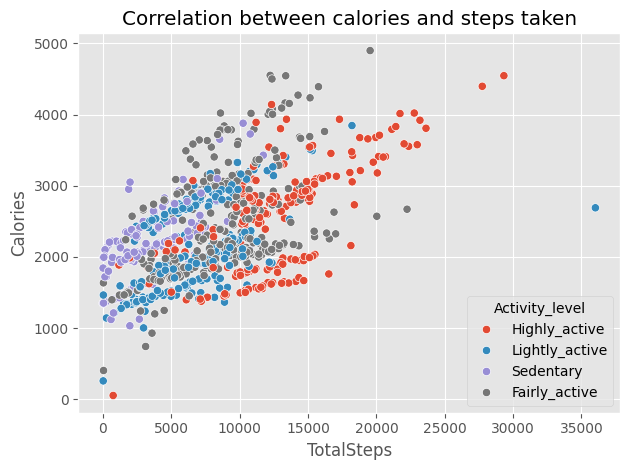

In [27]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# correlation between steps and calories burned
# df_sub.columns

ax = sns.scatterplot(x='TotalSteps', y='Calories',data=df_sub, hue='Activity_level') #plot the number of steps on the horizontal axis and the calories burned on the vertical axis.

plt.title('Correlation between calories and steps taken') # adds the headline
plt.tight_layout() # to make sure legends don't overlap
plt.show()  # render the plt

We can see that the scatterplot show a direct relationship betweek steps and calories. The more steps taken, the more calories are burnt. Also we divided the dots by colors using the Activity_level category we created before to see which group represents which data.
We can also see there are some outliers as well. One user is highly active but has low steps and calories burnt. One user us low calories burnt but incredibly high steps taken.

## Average number of steps per day
Lets visualize the average number of steps taken each day.

[np.float64(8949.282608695652), np.float64(8157.597122302158), np.float64(8185.398496240601), np.float64(7820.641666666666), np.float64(8946.628318584071), np.float64(7626.554545454545), np.float64(8488.218181818182)]


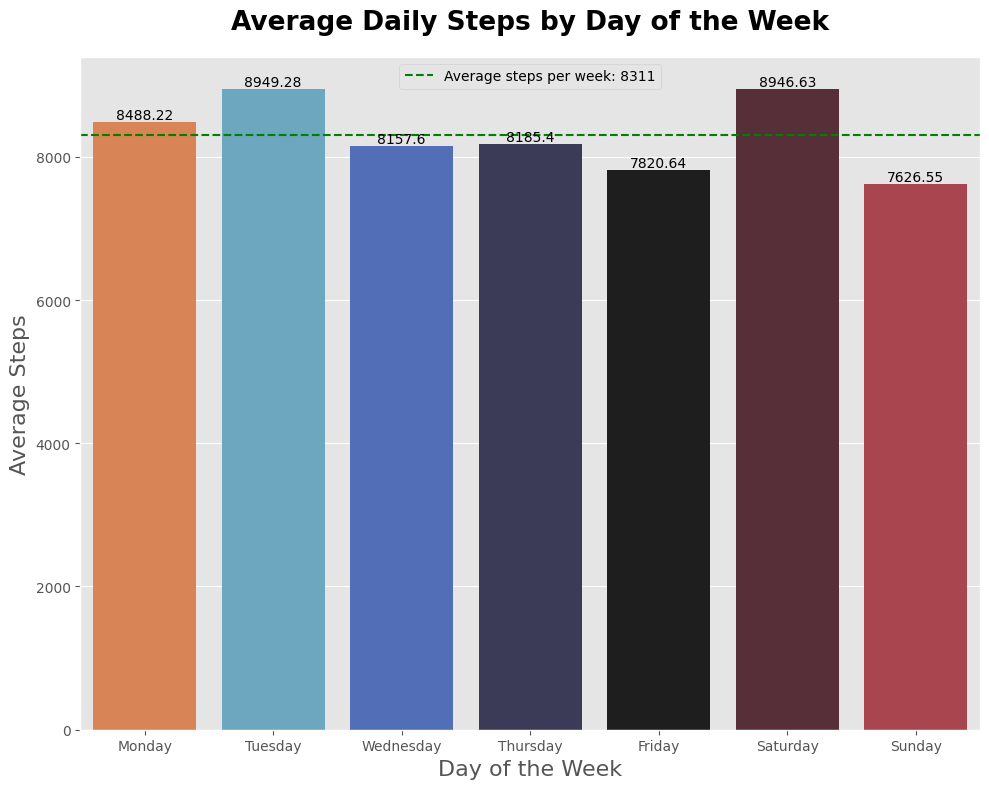

In [28]:
# average steps per day

# Set the order for days of the week according to our data
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# create a figure using matplotlib
plt.figure(figsize=(10,8))

# seaborn automatically groups the data by weekday and calculates the mean. we can do it manually if the data is not the way want it to be.
# assigning the barplot to a variable allows to access the individual bars inside them to add labels and such
mybarchart = sns.barplot(data=df_sub, x='day_of_week', y='TotalSteps', order=day_order, hue='day_of_week', palette='icefire', errorbar=None)# errorbar=None removes the black lines on top of the bar graph

# adding label for the values of each day of the week
for bars_value in mybarchart.containers:
    mybarchart.bar_label(bars_value)
    

# Trying something new and kinda useless but still
bar_heights = [] # a list for average total steps for each day of the week
for bars_value in mybarchart.patches: #In Matplotlib, each bar is a "patch"
    values = bars_value.get_height()  #get_height() method to pull the numerical value
    bar_heights.append(values)
    
print(bar_heights)
average_steps = sum(bar_heights) / len(bar_heights)



# figure labels
plt.title('Average Daily Steps by Day of the Week',fontsize=19,pad=20 , fontweight='bold')
plt.xlabel('Day of the Week', fontsize=16)
plt.ylabel('Average Steps', fontsize=16)

plt.axhline(y=average_steps, color='green', linestyle='--', label=f'Average steps per week: {round(average_steps.item())}',  ) # item() function to get the value from numpy values

plt.tight_layout()
plt.legend()
plt.show()


## Percentage of daily activity in minutes
Let's create a pie chart that shows time spent on various activity states.

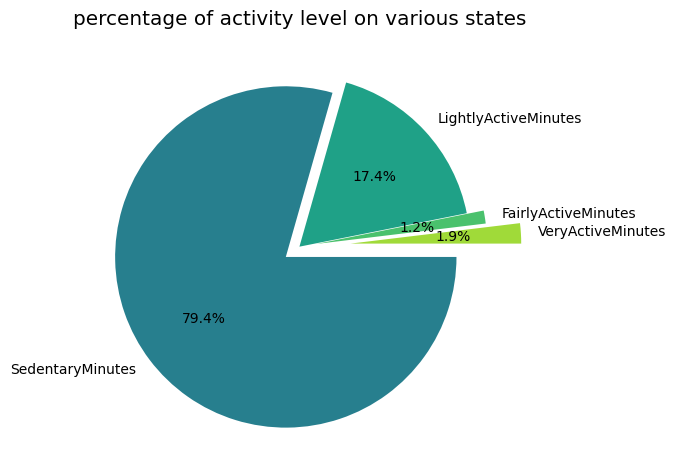

In [29]:
Total_VeryActiveMinutes = df_sub['VeryActiveMinutes'].sum()
Total_FairlyActiveMinutes=df_sub['FairlyActiveMinutes'].sum()
Total_LightlyActiveMinutes=df_sub['LightlyActiveMinutes'].sum()
Total_SedentaryMinutes=df_sub['SedentaryMinutes'].sum()

pie_slices=[Total_VeryActiveMinutes,Total_FairlyActiveMinutes,Total_LightlyActiveMinutes,Total_SedentaryMinutes] # slices for the pie
labels=['VeryActiveMinutes', 'FairlyActiveMinutes', 'LightlyActiveMinutes', 'SedentaryMinutes'] #labels for the slices

explode = [0.3,0.1,0,0.1] #Pops out the slices 

plt.pie(pie_slices, labels = labels, explode = explode, colors=sns.color_palette('viridis_r'), autopct = '%1.1f%%' ) # to show percentages inside the pie: autopct = '%1.1f%%'

plt.title('percentage of activity level on various states')
plt.tight_layout()
plt.show()

The pie chart shows that users are in a sedentary state most of the time, and only about 2% of the time are engaged in active exercises. This could mean that the device is tracking the time when the users are in bed or working on a desk.

## Relation of activity to calories burned
Does engaging in high activity  mean burning more calories to stay fit? Let's find out by making a scatterplot plotting calories burned for each kind of activity.

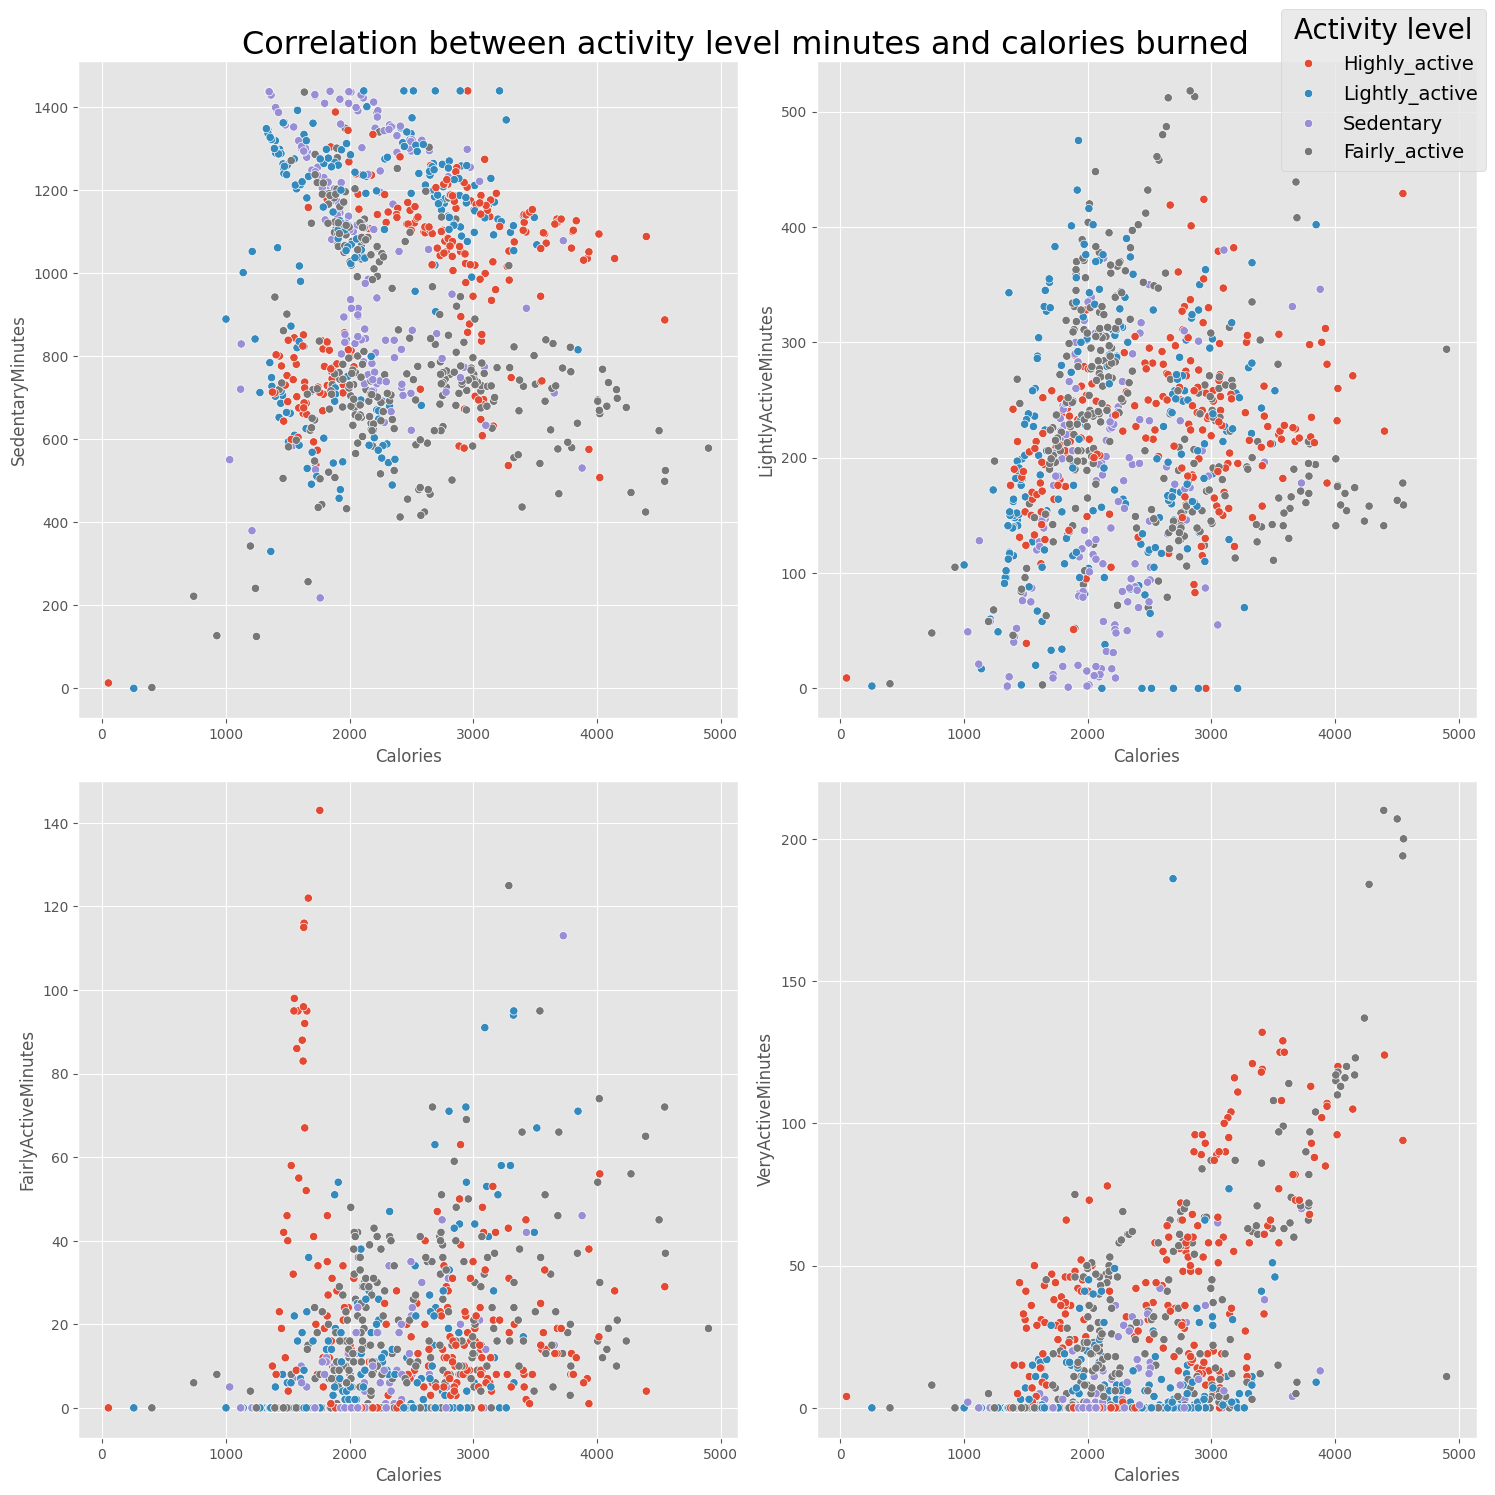

In [30]:
# relation for calories vs activity state

# using the variable axs for multiple Axes since its for four states
fig, axs= plt.subplots(nrows=2, ncols=2, figsize=(15,15))

# sedentary
sns.scatterplot(data=df_sub, x='Calories', y= 'SedentaryMinutes', hue='Activity_level', ax = axs[0,0], legend=False )

#LightlyActiveMinutes
sns.scatterplot(data=df_sub, x='Calories', y= 'LightlyActiveMinutes', hue='Activity_level', ax = axs[0,1], legend=False)

# FairlyActiveMinutes
sns.scatterplot(data=df_sub, x='Calories', y= 'FairlyActiveMinutes', hue='Activity_level', ax = axs[1,0], legend=False )

# VeryActiveMinutes
#  leave the legend 'True' for the last one temporarily to grab the labels and move them outside
sns.scatterplot(data=df_sub, x='Calories', y= 'VeryActiveMinutes', hue='Activity_level', ax = axs[1,1], legend=True )

# add the legend to the figure
fig.legend(title = 'Activity level', title_fontsize=20,fontsize=14, loc='outside right upper',frameon=True)

# We can also do this for legend. its another way. just comment the .remove function below.
# plt.legend(title='Activity level',title_fontsize=20,bbox_to_anchor=(1.8,2.2),fontsize=18,frameon=True,scatterpoints=1)

# remove the redundant legend
axs[1,1].get_legend().remove()

fig.suptitle('Correlation between activity level minutes and calories burned', fontsize=23)

plt.tight_layout()
plt.show()

Here we can see that time spent doing highly active exercises does somewhat correlate to more calories spent as the time spent on sedentary activities has overall low calories spent and time spent on high activity has higher calories spent.

## User categorization visualization
Let's see what percentage of user are highly active and what percentage of user are sedentary so we can see what is the target demographic for future marketing decisions.

Activity_level
Fairly_active     10
Lightly_active     9
Highly_active      7
Sedentary          7
Name: count, dtype: int64


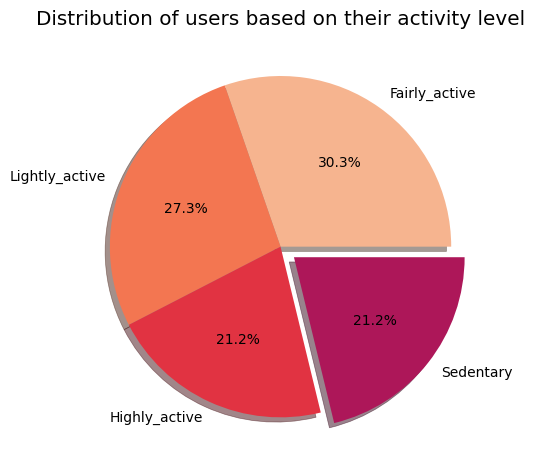

In [31]:
# user categorization visualization

# we can't use the df_sub because then it will count the users based on their activity level,
# but we want to show it based on unique users that were grouped by id
# so either we can group it again based on same id or we can use the dataframe we created during user  avg_step_perID

# get the user counts based on their activity level from our summary dataframe that grouped the 33 unuque rows
user_count = avg_step_perID['Activity_level'].value_counts()
print(user_count)

# let's create a pie chart
labels= user_count.index #get the list of activity level indexes
explode = [0,0,0,0.1] #Pops out the slices 

plt.pie(user_count, labels=labels, explode=explode, colors=sns.color_palette('rocket_r'), autopct='%1.1f%%', shadow=True)
plt.title('Distribution of users based on their activity level')
plt.tight_layout()
plt.show()

Here, we can see that 21.2% of users are mostly sedentary and 21.2% of users are highly active. This model can be more accurate but what's stopping us now is not having enough data. With the data of just 33 users, this is all we can show.

# Phase 6: Act

## Conclusion
From our analysis,  we have learned many things about the data. When we cleaned, we found that some devices were never turned on while some devices were turned on but not used during any kinds of activities.

After removing such data so as they don't skew our final analysis, we found many things. We found that the average steps taken was in the range 8300 which is not very close to the recommended 10000 steps. This means many users aren't engaging on proper healthy exercises. This means bellabeat must put some effort on their marketing strategy to encourage users to be more active.
While most users are fairly active,  21% of users are quite sedentary. This is the market bellabeat to focus on.

## Limitation
This analysis had many limitations. The data was not up to date as it is from 2016 and it is also for a period of 1 month. The demography of the data is also not available as bellabeat mainly focuses on woman's health. There wasn't enough amount data of users as well as there were only 33 unique users. If we can work on this, we can get even much more accurate picture of what we are working on.

## Recommendations:
Here are some recommendations that I would like to make:
* While most users do engage in some kind of activity, there should be a reward system for engaging in more active activities.
* The bellabeat app should keep in count the steps taken by the user and reward/remind them based on their activity.

